## Task 1: Data Loading & Exploration

In [1]:
import pandas as pd

df = pd.read_csv("Housing.csv")

## Displaying the First 10 Rows of the Dataset

In [2]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


## Dataset Shape

In [3]:
print("Rows and Columns:", df.shape)

Rows and Columns: (545, 13)


## Identifying Target and Feature Columns


In [4]:
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [5]:
target = "price"

features = df.drop("price", axis=1)

print("Target Column:", target)
print("\nFeature Columns:")
print(features.columns)

Target Column: price

Feature Columns:
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')


## Checking Missing Values

In [6]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

## Dataset Information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


## Task 2: Data Cleaning

In [8]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [9]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (545, 13)


In [10]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [11]:
df.select_dtypes(include='object').columns

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [12]:
df = pd.get_dummies(df, drop_first=True)

df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   parking                          545 non-null    int64
 6   mainroad_yes                     545 non-null    bool 
 7   guestroom_yes                    545 non-null    bool 
 8   basement_yes                     545 non-null    bool 
 9   hotwaterheating_yes              545 non-null    bool 
 10  airconditioning_yes              545 non-null    bool 
 11  prefarea_yes                     545 non-null    bool 
 12  furnishingstatus_semi-furnished  545 non-null    b

### Feature Selection

The dataset did not contain any irrelevant identifier columns or features unrelated to house price prediction. Therefore, all available housing-related features were retained for model training, as they provide useful information for predicting property prices.

## Task 3: Model Building and Evaluation

In [14]:
X = df.drop("price", axis=1)
y = df["price"]

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (436, 13)
Testing Set Shape: (109, 13)


### Linear Regression

In [16]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

LinearRegression()

In [17]:
y_pred = lr_model.predict(X_test)

In [18]:
lr_predictions = lr_model.predict(X_test)

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr_mae = mean_absolute_error(y_test, lr_predictions)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))

lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Results")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R² Score:", lr_r2)

Linear Regression Results
MAE : 970043.403920164
RMSE: 1324506.9600914388
R² Score: 0.6529242642153184


### Random Forest Regressor

In [20]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [21]:
rf_predictions = rf_model.predict(X_test)

In [22]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Results
MAE : 1021546.0353211008
RMSE: 1400565.9728553821
R² Score: 0.611918531405699


In [23]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R² Score": [lr_r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


### Model Comparison

Both Linear Regression and Random Forest Regressor were evaluated using MAE, RMSE, and R² Score.

The Linear Regression model achieved a lower prediction error and a higher R² Score compared to the Random Forest model. Therefore, Linear Regression was selected as the better-performing model for this housing dataset.

This suggests that the relationship between the housing features and price is reasonably linear, allowing Linear Regression to generalize better on unseen data.

In [24]:
comparison.sort_values("R² Score", ascending=False)

,Model,MAE,RMSE,R² Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


### Model Evaluation Summary

Two machine learning models were trained and evaluated for house price prediction.

The Linear Regression model achieved an R² Score of 0.653, outperforming the Random Forest Regressor, which achieved an R² Score of 0.612.

Additionally, Linear Regression produced lower MAE and RMSE values, indicating more accurate predictions on the test dataset.

Therefore, Linear Regression was selected as the final model for this project.

In [25]:
import os

os.makedirs("charts", exist_ok=True)

# Task 4: Data Visualization

Data visualization helps identify patterns, trends, and relationships within the housing dataset. The following charts provide insights into house price distribution, feature correlations, and model performance.

## Chart 1: Distribution of House Prices

This histogram visualizes the distribution of house prices in the dataset. It helps identify whether the prices are evenly distributed or concentrated within specific price ranges.

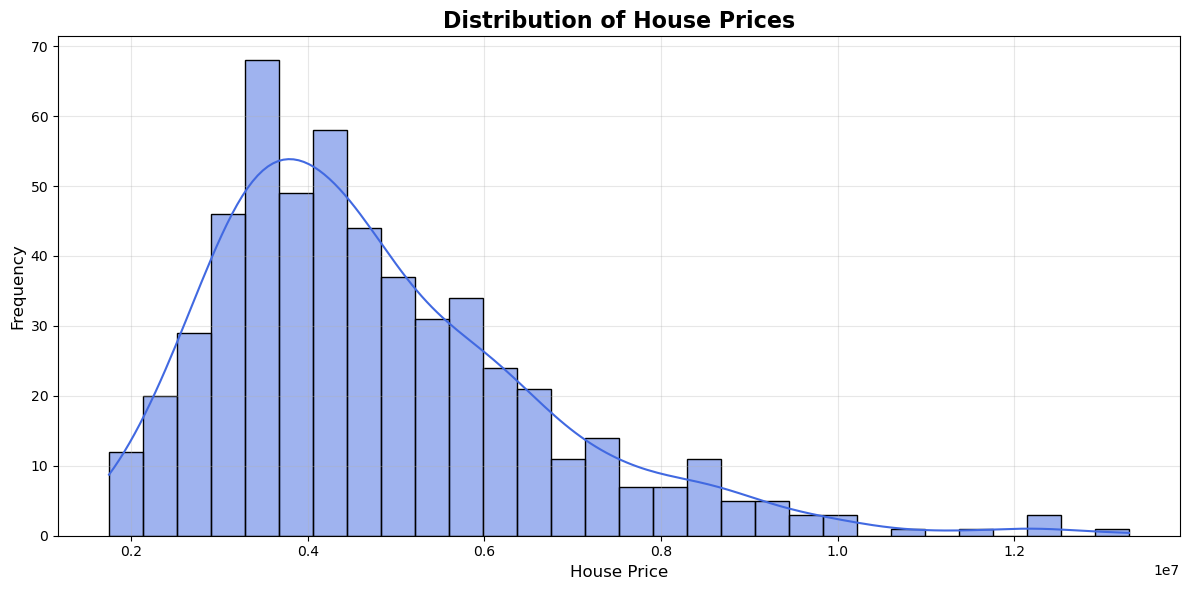

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.histplot(
    df['price'],
    bins=30,
    kde=True,
    color='royalblue'
)

plt.title("Distribution of House Prices", fontsize=16, fontweight='bold')
plt.xlabel("House Price", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "charts/price_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

**Observation:**  
Most house prices are concentrated within a particular range, indicating that the distribution is not perfectly uniform. A few properties have significantly higher prices, which may be considered premium houses.

## Chart 2: Correlation Heatmap

The correlation heatmap illustrates the strength of relationships between different variables in the dataset. Strong positive correlations are shown with higher values, helping identify the features that have the greatest influence on house prices.

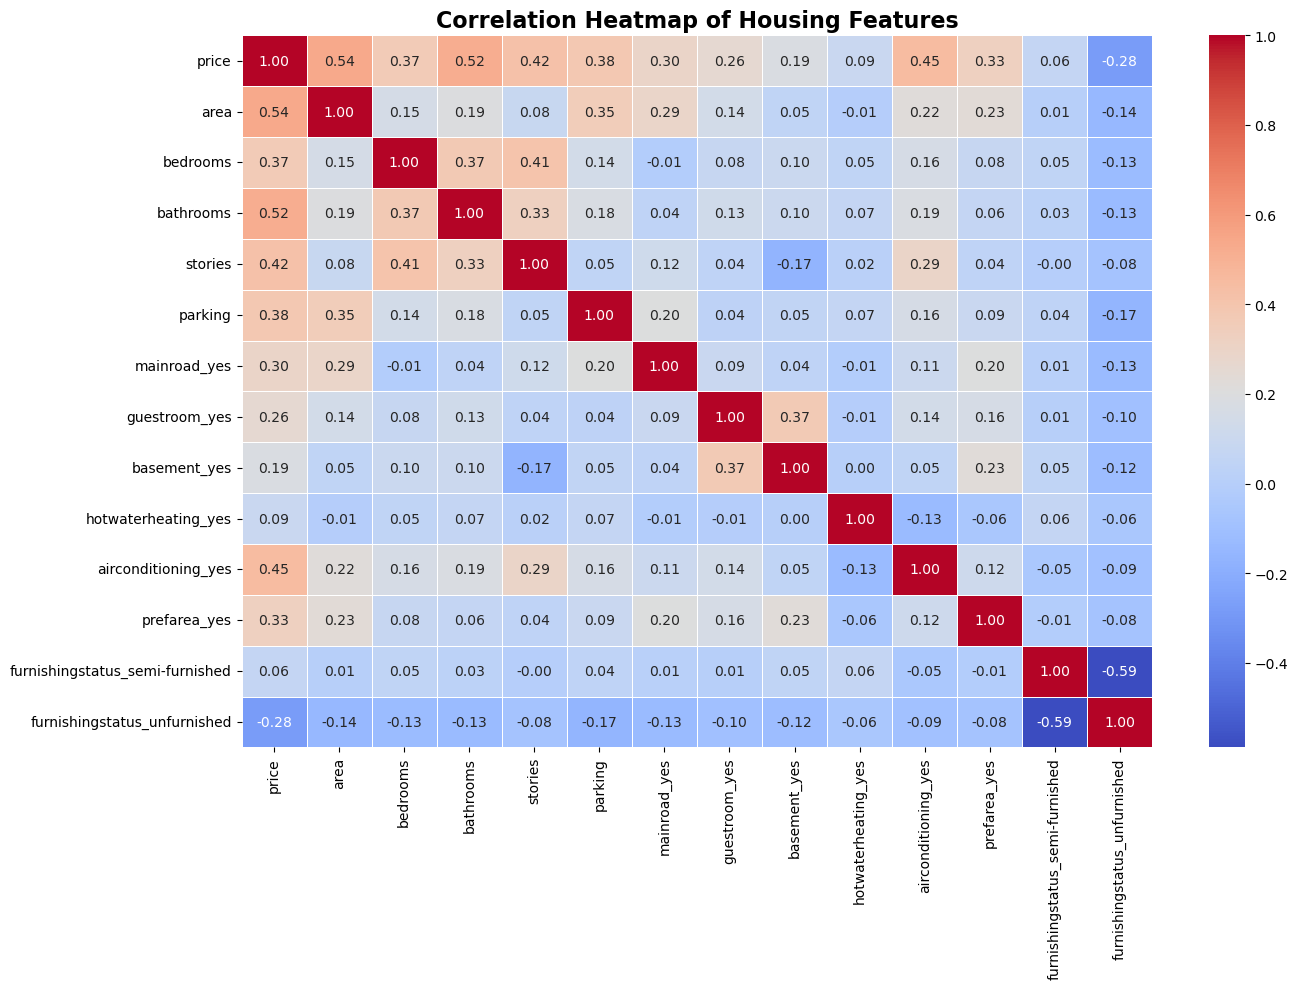

In [27]:
plt.figure(figsize=(14,10))

correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title(
    "Correlation Heatmap of Housing Features",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "charts/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Observation:**  
Area, bathrooms, air conditioning, parking, and number of stories show a positive correlation with house price, indicating that these features contribute significantly to property value.

## Chart 3: Actual vs Predicted House Prices

This scatter plot compares actual house prices with the prices predicted by the Linear Regression model. Points closer to the diagonal line indicate more accurate predictions.

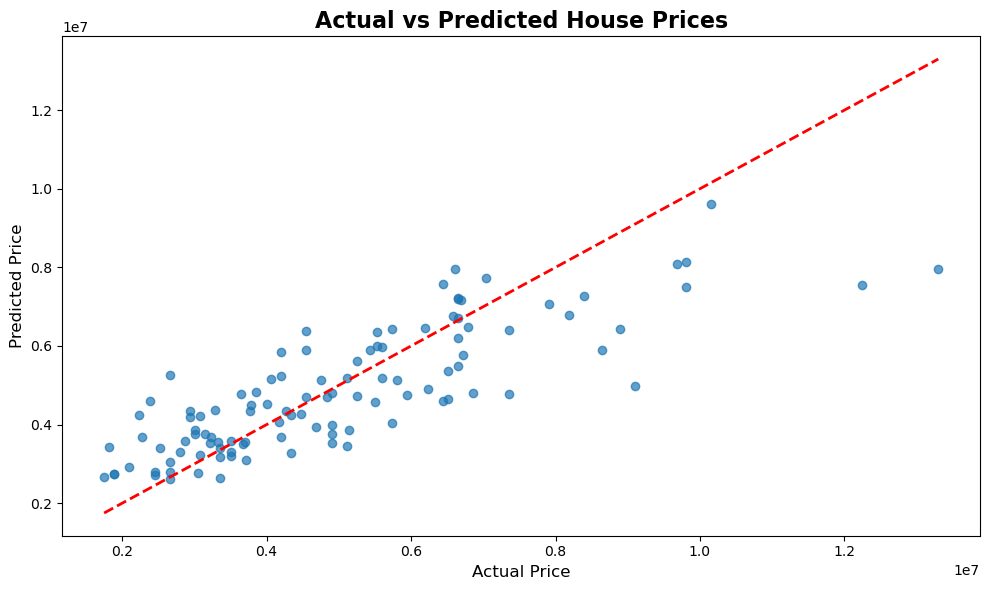

In [28]:
plt.figure(figsize=(10,6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.title(
    "Actual vs Predicted House Prices",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Actual Price", fontsize=12)
plt.ylabel("Predicted Price", fontsize=12)

plt.tight_layout()

plt.savefig(
    "charts/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Observation:**  
Most points lie close to the diagonal reference line, suggesting that the Linear Regression model is able to predict house prices with reasonable accuracy.

## Chart 4: Feature Importance Analysis

This chart displays the relative importance of different housing features in predicting house prices using the Random Forest Regressor. Features with higher importance scores contribute more significantly to the prediction process.

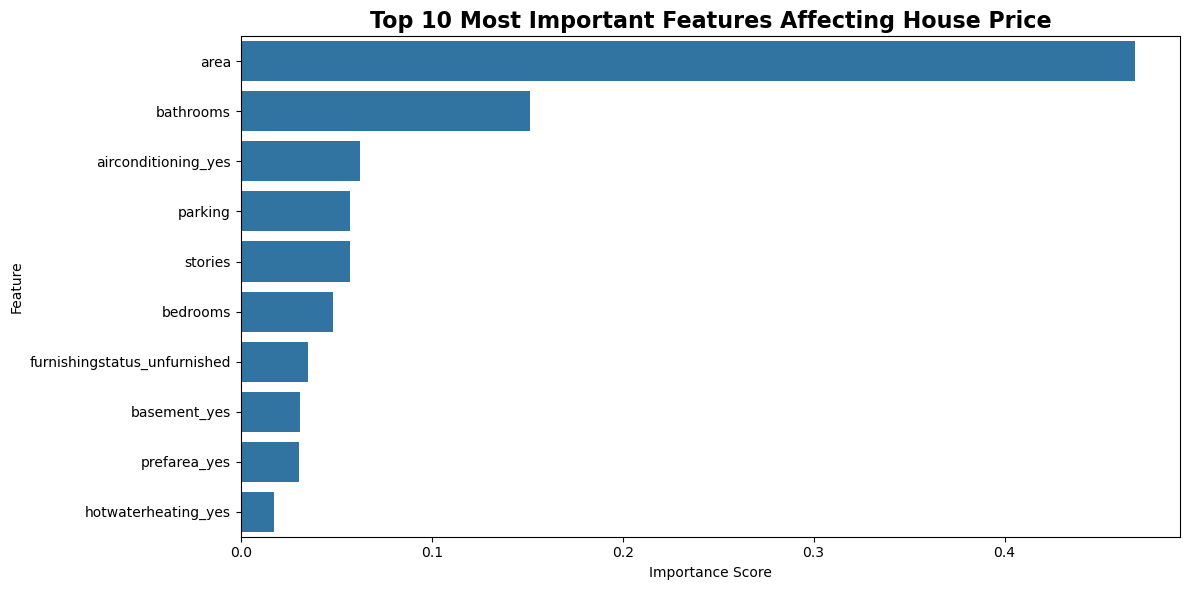

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title(
    'Top 10 Most Important Features Affecting House Price',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.tight_layout()

plt.savefig(
    'charts/feature_importance.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

**Observation:**  
Feature importance analysis indicates that area is the most influential factor affecting house price, followed by bathrooms, air conditioning, parking, and stories.

# Task 5: Insights & Summary

## Key Findings

The analysis revealed that area, number of bathrooms, parking spaces, number of stories, and air conditioning are among the most influential factors affecting house prices. The Linear Regression model achieved an R² score of approximately 0.65, which means it can explain about 65% of the variation in house prices and provides reasonably accurate predictions. One surprising observation was that the Random Forest model performed slightly worse than Linear Regression on this dataset. It was also interesting to see that some features had a weaker impact on price than expected. Based on these findings, a real estate business should focus on larger properties with better amenities, as these factors significantly increase property value and can help improve pricing strategies

## Model Comparison

| Model | R² Score |
|---------|---------|
| Linear Regression | 0.653 |
| Random Forest | 0.612 |

The Linear Regression model achieved the highest R² score and lower prediction errors, making it the better-performing model for this dataset.

## Conclusion

This project successfully developed a house price prediction system using machine learning techniques. Exploratory data analysis, visualization, feature engineering, and model evaluation were performed to understand the factors affecting house prices.

Among all features, house area emerged as the strongest predictor of price. Based on evaluation metrics, the Linear Regression model provided the best balance between accuracy and generalization for this dataset.

## Future Improvements

- Collect a larger housing dataset to improve model generalization.
- Perform hyperparameter tuning for Random Forest.
- Experiment with advanced models such as XGBoost and Gradient Boosting.
- Develop a web application for real-time house price prediction.